In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [9]:
df = pd.read_csv("Covid_19_Clean_Complete (2).csv")

In [10]:
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [11]:
df.isnull().sum()

Province/State    34404
Country/Region        0
Lat                   0
Long                  0
Date                  0
Confirmed             0
Deaths                0
Recovered             0
Active                0
WHO Region            0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.columns

Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed',
       'Deaths', 'Recovered', 'Active', 'WHO Region'],
      dtype='object')

In [14]:
df["Province/State"].value_counts()

Province/State
Australian Capital Territory    188
New South Wales                 188
Northern Territory              188
Queensland                      188
South Australia                 188
                               ... 
Anguilla                        188
British Virgin Islands          188
Turks and Caicos Islands        188
Falkland Islands (Malvinas)     188
Saint Pierre and Miquelon       188
Name: count, Length: 78, dtype: int64

In [15]:
df.shape

(49068, 10)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [17]:
df.rename(columns = {
    "Province/State" : "state",
    "Country/Region" : "country"
},inplace = True)

In [18]:
df

,state,country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


# Confirm Cases

In [19]:
confirmed_cases = df.groupby(["Date"])["Confirmed"].sum().reset_index()
confirmed_cases

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


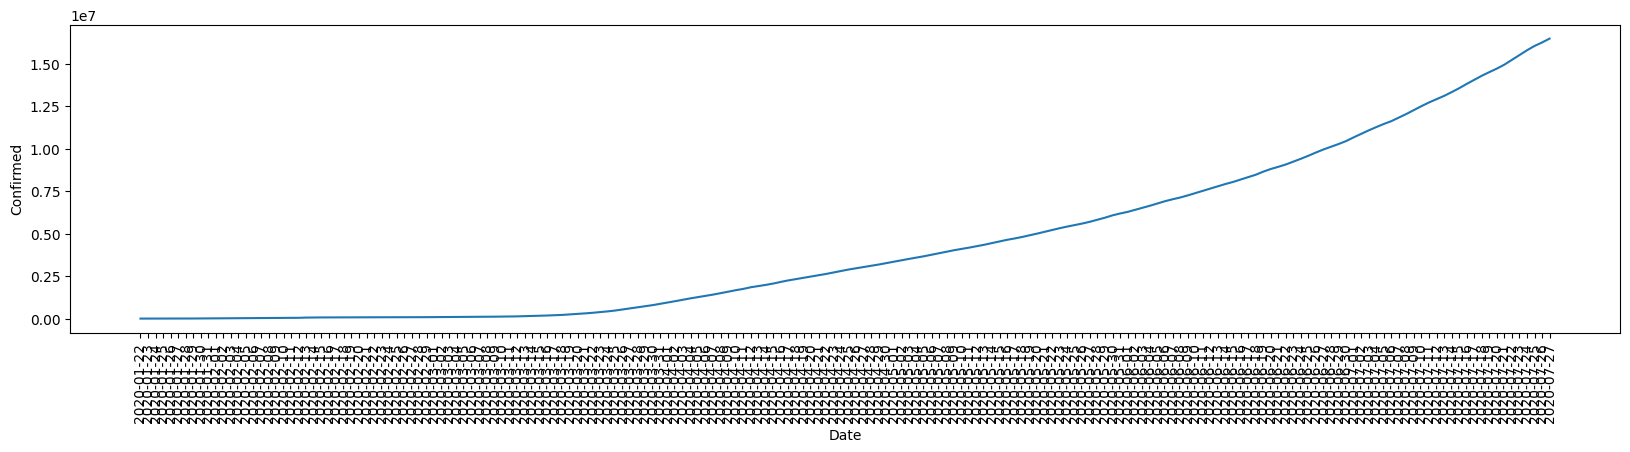

In [20]:
plt.figure(figsize=(20,4))
sns.lineplot(data = confirmed_cases, x = "Date", y = "Confirmed")
plt.xticks(rotation = 90)
plt.show()

# Death Cases

In [21]:
death_cases = df.groupby(["Date"])["Deaths"].sum().reset_index()
death_cases

,Date,Deaths
0,2020-01-22,17
1,2020-01-23,18
2,2020-01-24,26
3,2020-01-25,42
4,2020-01-26,56
...,...,...
183,2020-07-23,633506
184,2020-07-24,639650
185,2020-07-25,644517
186,2020-07-26,648621


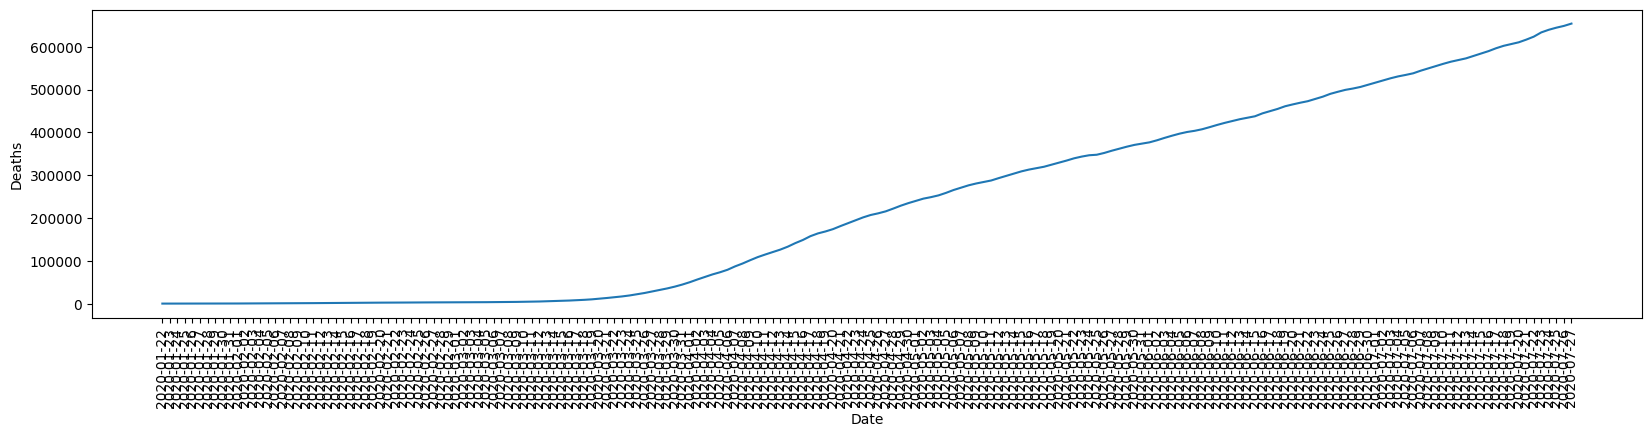

In [22]:
plt.figure(figsize=(20,4))
sns.lineplot(data=death_cases, x="Date", y="Deaths")
plt.xticks(rotation=90)
plt.show()

# Recovered Cases

In [23]:
Recovered_Cases = df.groupby(["Date"])["Recovered"].sum().reset_index()
Recovered_Cases

,Date,Recovered
0,2020-01-22,28
1,2020-01-23,30
2,2020-01-24,36
3,2020-01-25,39
4,2020-01-26,52
...,...,...
183,2020-07-23,8710969
184,2020-07-24,8939705
185,2020-07-25,9158743
186,2020-07-26,9293464


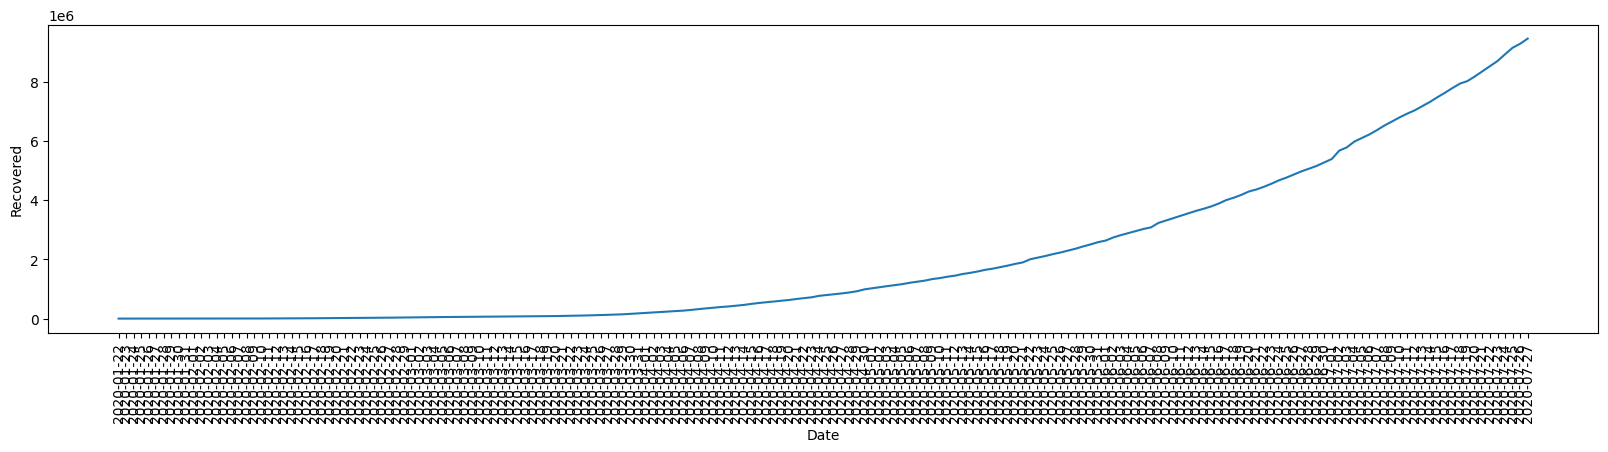

In [24]:
plt.figure(figsize = (20,4))
sns.lineplot(data=Recovered_Cases, x="Date", y="Recovered")
plt.xticks(rotation=90)
plt.show()

# Active Cases

In [25]:
Active_cases = df.groupby(["Date"])["Active"].sum().reset_index()
Active_cases

,Date,Active
0,2020-01-22,510
1,2020-01-23,606
2,2020-01-24,879
3,2020-01-25,1353
4,2020-01-26,2010
...,...,...
183,2020-07-23,6166006
184,2020-07-24,6212290
185,2020-07-25,6243930
186,2020-07-26,6309711


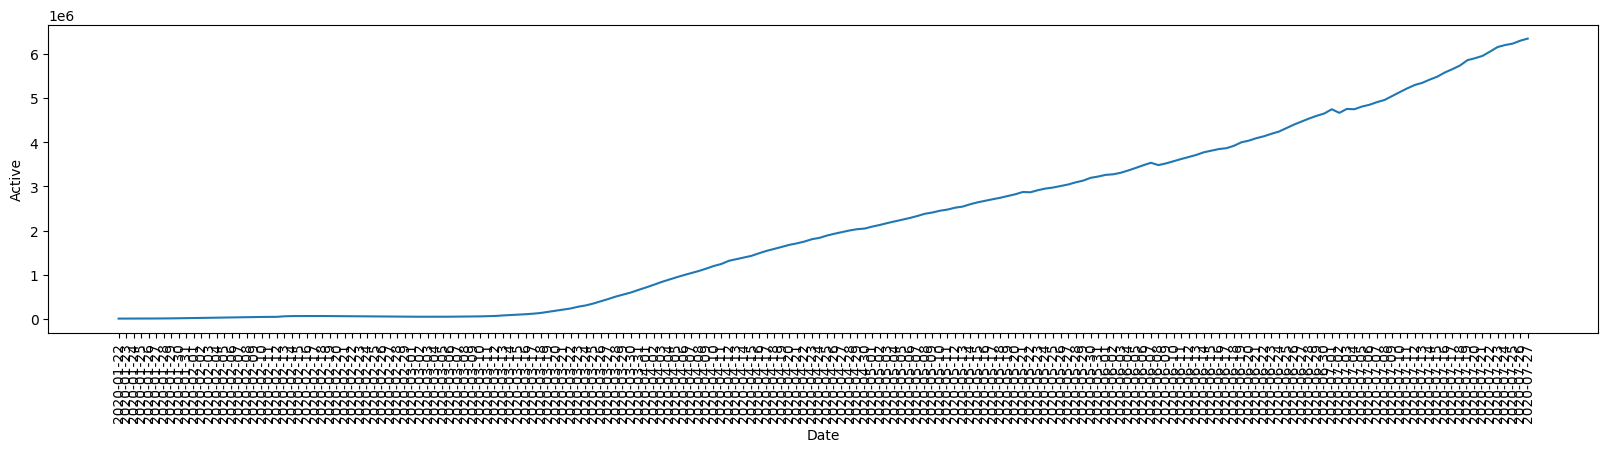

In [26]:
plt.figure(figsize=(20,4))
sns.lineplot(data=Active_cases, x="Date", y="Active")
plt.xticks(rotation=90)
plt.show()

In [27]:
# Lets find most affected countries

In [28]:
df.columns

Index(['state', 'country', 'Lat', 'Long', 'Date', 'Confirmed', 'Deaths',
       'Recovered', 'Active', 'WHO Region'],
      dtype='object')

In [29]:
data_countries = df.groupby(["country"])[[ 'Confirmed', 'Deaths','Recovered', 'Active']].sum().reset_index()
data_countries

,country,Confirmed,Deaths,Recovered,Active
0,Afghanistan,1936390,49098,798240,1089052
1,Albania,196702,5708,118877,72117
2,Algeria,1179755,77972,755897,345886
3,Andorra,94404,5423,69074,19907
4,Angola,22662,1078,6573,15011
...,...,...,...,...,...
182,West Bank and Gaza,233461,1370,61124,170967
183,Western Sahara,901,63,648,190
184,Yemen,67180,17707,23779,25694
185,Zambia,129421,2643,83611,43167


In [30]:
# Top 3 Countries

In [31]:
top3_confirmed = data_countries.sort_values(by="Confirmed", ascending=False).head(3)
top3_confirmed

,country,Confirmed,Deaths,Recovered,Active
173,US,224345948,11011411,56353416,156981121
23,Brazil,89524967,3938034,54492873,31094060
138,Russia,45408411,619385,25120448,19668578


In [32]:
top3_Deaths = data_countries.sort_values(by="Deaths", ascending=False).head(3)
top3_Deaths

,country,Confirmed,Deaths,Recovered,Active
173,US,224345948,11011411,56353416,156981121
177,United Kingdom,26748587,3997775,126217,22624595
23,Brazil,89524967,3938034,54492873,31094060


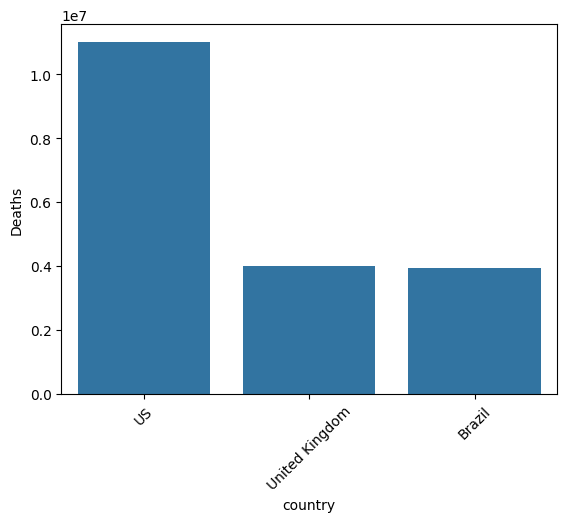

In [33]:
sns.barplot(data = top3_Deaths ,x ="country" , y="Deaths")
plt.xticks(rotation=45)
plt.show()

In [34]:
top3_Recovered = data_countries.sort_values(by="Recovered", ascending=False).head(3)
top3_Recovered

,country,Confirmed,Deaths,Recovered,Active
173,US,224345948,11011411,56353416,156981121
23,Brazil,89524967,3938034,54492873,31094060
138,Russia,45408411,619385,25120448,19668578


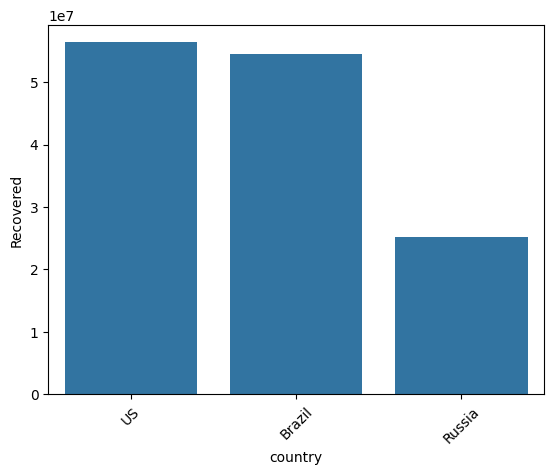

In [35]:
sns.barplot(data = top3_Recovered ,x ="country" , y="Recovered")
plt.xticks(rotation=45)
plt.show()

In [36]:
top3_Active = data_countries.sort_values(by="Active", ascending=False).head(3)
top3_Active

,country,Confirmed,Deaths,Recovered,Active
173,US,224345948,11011411,56353416,156981121
23,Brazil,89524967,3938034,54492873,31094060
177,United Kingdom,26748587,3997775,126217,22624595


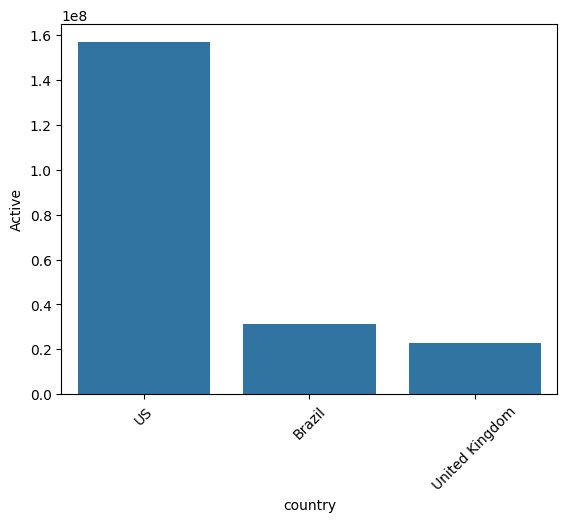

In [37]:
sns.barplot(data = top3_Active ,x ="country" , y="Active")
plt.xticks(rotation=45)
plt.show()

In [38]:
us = df[df['country'] == "US"]
us

,state,country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
223,NaN,US,40.0,-100.0,2020-01-22,1,0,0,1,Americas
484,NaN,US,40.0,-100.0,2020-01-23,1,0,0,1,Americas
745,NaN,US,40.0,-100.0,2020-01-24,2,0,0,2,Americas
1006,NaN,US,40.0,-100.0,2020-01-25,2,0,0,2,Americas
1267,NaN,US,40.0,-100.0,2020-01-26,5,0,0,5,Americas
...,...,...,...,...,...,...,...,...,...,...
47986,NaN,US,40.0,-100.0,2020-07-23,4038816,144430,1233269,2661117,Americas
48247,NaN,US,40.0,-100.0,2020-07-24,4112531,145560,1261624,2705347,Americas
48508,NaN,US,40.0,-100.0,2020-07-25,4178970,146465,1279414,2753091,Americas
48769,NaN,US,40.0,-100.0,2020-07-26,4233923,146935,1297863,2789125,Americas


In [39]:
data_us = us.groupby(["Date"])[[ 'Confirmed', 'Deaths','Recovered', 'Active']].sum().reset_index()
data_us

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,1,0,0,1
1,2020-01-23,1,0,0,1
2,2020-01-24,2,0,0,2
3,2020-01-25,2,0,0,2
4,2020-01-26,5,0,0,5
...,...,...,...,...,...
183,2020-07-23,4038816,144430,1233269,2661117
184,2020-07-24,4112531,145560,1261624,2705347
185,2020-07-25,4178970,146465,1279414,2753091
186,2020-07-26,4233923,146935,1297863,2789125


In [40]:
Brazil = df[df['country'] == "Brazil"]
Brazil

,state,country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
28,NaN,Brazil,-14.235,-51.9253,2020-01-22,0,0,0,0,Americas
289,NaN,Brazil,-14.235,-51.9253,2020-01-23,0,0,0,0,Americas
550,NaN,Brazil,-14.235,-51.9253,2020-01-24,0,0,0,0,Americas
811,NaN,Brazil,-14.235,-51.9253,2020-01-25,0,0,0,0,Americas
1072,NaN,Brazil,-14.235,-51.9253,2020-01-26,0,0,0,0,Americas
...,...,...,...,...,...,...,...,...,...,...
47791,NaN,Brazil,-14.235,-51.9253,2020-07-23,2287475,84082,1620313,583080,Americas
48052,NaN,Brazil,-14.235,-51.9253,2020-07-24,2343366,85238,1693214,564914,Americas
48313,NaN,Brazil,-14.235,-51.9253,2020-07-25,2394513,86449,1785359,522705,Americas
48574,NaN,Brazil,-14.235,-51.9253,2020-07-26,2419091,87004,1812913,519174,Americas


In [41]:
data_Brazil = Brazil.groupby(["Date"])[[ 'Confirmed', 'Deaths','Recovered', 'Active']].sum().reset_index()
data_Brazil

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,0,0,0,0
1,2020-01-23,0,0,0,0
2,2020-01-24,0,0,0,0
3,2020-01-25,0,0,0,0
4,2020-01-26,0,0,0,0
...,...,...,...,...,...
183,2020-07-23,2287475,84082,1620313,583080
184,2020-07-24,2343366,85238,1693214,564914
185,2020-07-25,2394513,86449,1785359,522705
186,2020-07-26,2419091,87004,1812913,519174


In [42]:
Russia = df[df['country'] == "Russia"]
Russia

,state,country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
185,NaN,Russia,61.52401,105.318756,2020-01-22,0,0,0,0,Europe
446,NaN,Russia,61.52401,105.318756,2020-01-23,0,0,0,0,Europe
707,NaN,Russia,61.52401,105.318756,2020-01-24,0,0,0,0,Europe
968,NaN,Russia,61.52401,105.318756,2020-01-25,0,0,0,0,Europe
1229,NaN,Russia,61.52401,105.318756,2020-01-26,0,0,0,0,Europe
...,...,...,...,...,...,...,...,...,...,...
47948,NaN,Russia,61.52401,105.318756,2020-07-23,793720,12873,579295,201552,Europe
48209,NaN,Russia,61.52401,105.318756,2020-07-24,799499,13026,587728,198745,Europe
48470,NaN,Russia,61.52401,105.318756,2020-07-25,805332,13172,596064,196096,Europe
48731,NaN,Russia,61.52401,105.318756,2020-07-26,811073,13249,599172,198652,Europe


In [43]:
data_Russia = Russia.groupby(["Date"])[[ 'Confirmed', 'Deaths','Recovered', 'Active']].sum().reset_index()
data_Russia

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,0,0,0,0
1,2020-01-23,0,0,0,0
2,2020-01-24,0,0,0,0
3,2020-01-25,0,0,0,0
4,2020-01-26,0,0,0,0
...,...,...,...,...,...
183,2020-07-23,793720,12873,579295,201552
184,2020-07-24,799499,13026,587728,198745
185,2020-07-25,805332,13172,596064,196096
186,2020-07-26,811073,13249,599172,198652


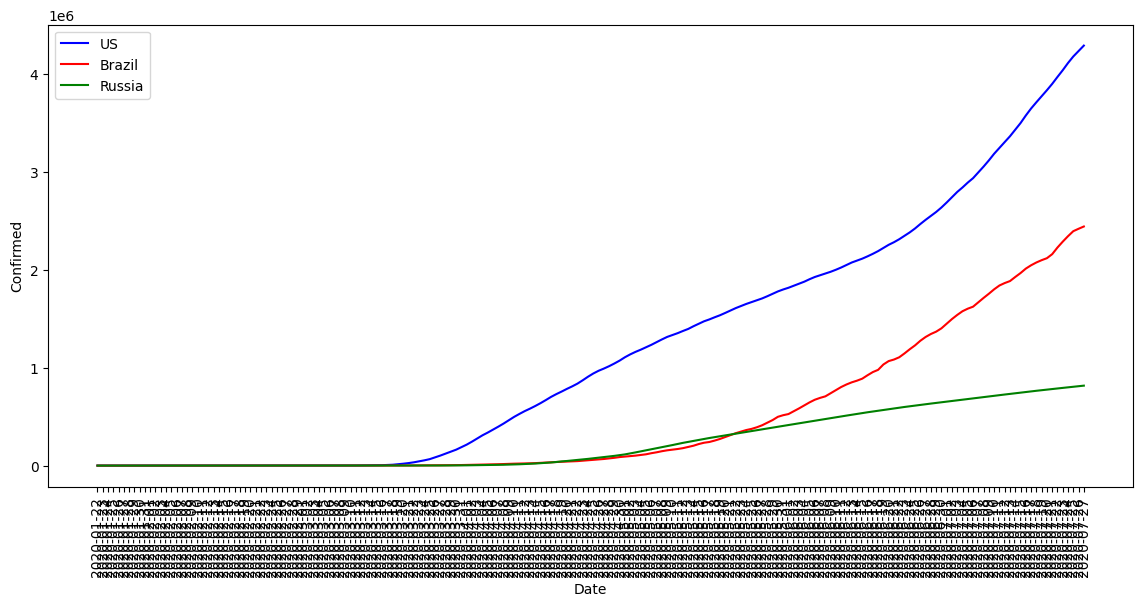

In [44]:
plt.figure(figsize=(14,6))
sns.lineplot(data = data_us, x="Date",y="Confirmed",color= "blue",label="US")
sns.lineplot(data = data_Brazil, x="Date",y="Confirmed",color= "red",label="Brazil")
sns.lineplot(data = data_Russia, x="Date",y="Confirmed",color= "green",label="Russia")
plt.xticks(rotation=90)
plt.show()

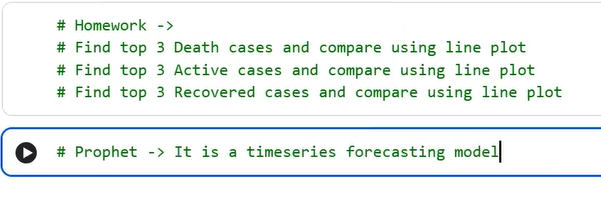

# Import Prophet developed by meta(Facebook)

In [45]:
!pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.1 MB 2.4 MB/s eta 0:00:05
   ----- ---------------------------------- 1.6/12.1 MB 2.6 MB/s eta 0:00:05
   ------ --------------------------------- 2.1/12.1 MB 2.5 MB/s eta 0:00:05
   --------- ------------------------------ 2.9/12.1 MB 2.7 MB/s eta 0:00:04
   ---------- ----------------------------- 3.1/12.1 MB 2.7 MB/s eta 0:00:04
   ----------- ---------------------------- 3.4/12.1 MB 2.5 MB/s eta 0:00:04
   ------------ --------------------------- 3.7/12.1 MB 2.2 MB/s eta 0:00:04
   ------------- -------------------------- 4.2/12.1 MB 2.2 MB/s eta 0:00:04
   ---------------- ----------------------- 5.0/12.1 MB 2.3 MB/s eta 0:00:04
   ------------------ --------------------- 5.5/12.1 MB 2.4 MB/s eta 0:00:03
   -------------------- ------------------- 6.3/12.1 MB 2.5 MB/s eta 0:00:03
   ----------

In [46]:
from prophet import Prophet

# Forecasting for a confirmed cases

In [47]:
confirmed_cases = df.groupby("Date")["Confirmed"].sum().reset_index()

In [48]:
confirmed_cases

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


In [49]:
# We need to rename the column as ds(datestamp) and y(value)
prophet_data = confirmed_cases.rename(columns={
    "Date" : "ds",
    "Confirmed" : "y"
})


In [50]:
prophet_data

,ds,y
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


In [51]:
model = Prophet()

In [52]:
model.fit(prophet_data)

23:25:37 - cmdstanpy - INFO - Chain [1] start processing
23:25:39 - cmdstanpy - INFO - Chain [1] done processing


In [53]:
Future_confirmed =  model.make_future_dataframe(periods=7) # for future 7 days

In [54]:
Future_confirmed

,ds
0,2020-01-22
1,2020-01-23
2,2020-01-24
3,2020-01-25
4,2020-01-26
...,...
190,2020-07-30
191,2020-07-31
192,2020-08-01
193,2020-08-02


In [55]:
forecast_confirmed = model.predict(Future_confirmed)
forecast_confirmed

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-9.356181e+03,-1.158137e+05,8.977007e+04,-9.356181e+03,-9.356181e+03,-10986.215104,-10986.215104,-10986.215104,-10986.215104,-10986.215104,-10986.215104,0.0,0.0,0.0,-2.034240e+04
1,2020-01-23,-6.667726e+03,-1.157892e+05,9.775008e+04,-6.667726e+03,-6.667726e+03,-1078.892495,-1078.892495,-1078.892495,-1078.892495,-1078.892495,-1078.892495,0.0,0.0,0.0,-7.746619e+03
2,2020-01-24,-3.979272e+03,-9.840890e+04,1.115793e+05,-3.979272e+03,-3.979272e+03,10103.254163,10103.254163,10103.254163,10103.254163,10103.254163,10103.254163,0.0,0.0,0.0,6.123982e+03
3,2020-01-25,-1.290817e+03,-8.232505e+04,1.245868e+05,-1.290817e+03,-1.290817e+03,13670.219215,13670.219215,13670.219215,13670.219215,13670.219215,13670.219215,0.0,0.0,0.0,1.237940e+04
4,2020-01-26,1.397637e+03,-9.868656e+04,1.228849e+05,1.397637e+03,1.397637e+03,7218.147794,7218.147794,7218.147794,7218.147794,7218.147794,7218.147794,0.0,0.0,0.0,8.615785e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,1.674928e+07,1.664531e+07,1.685747e+07,1.674327e+07,1.675533e+07,-1078.892495,-1078.892495,-1078.892495,-1078.892495,-1078.892495,-1078.892495,0.0,0.0,0.0,1.674820e+07
191,2020-07-31,1.695352e+07,1.685579e+07,1.707586e+07,1.694114e+07,1.696426e+07,10103.254163,10103.254163,10103.254163,10103.254163,10103.254163,10103.254163,0.0,0.0,0.0,1.696362e+07
192,2020-08-01,1.715776e+07,1.706127e+07,1.727850e+07,1.713725e+07,1.717416e+07,13670.219215,13670.219215,13670.219215,13670.219215,13670.219215,13670.219215,0.0,0.0,0.0,1.717143e+07
193,2020-08-02,1.736200e+07,1.725328e+07,1.748671e+07,1.733365e+07,1.738551e+07,7218.147794,7218.147794,7218.147794,7218.147794,7218.147794,7218.147794,0.0,0.0,0.0,1.736922e+07


In [56]:
forecast_confirmed[["yhat_lower","yhat_upper","yhat"]]

,yhat_lower,yhat_upper,yhat
0,-1.158137e+05,8.977007e+04,-2.034240e+04
1,-1.157892e+05,9.775008e+04,-7.746619e+03
2,-9.840890e+04,1.115793e+05,6.123982e+03
3,-8.232505e+04,1.245868e+05,1.237940e+04
4,-9.868656e+04,1.228849e+05,8.615785e+03
...,...,...,...
190,1.664531e+07,1.685747e+07,1.674820e+07
191,1.685579e+07,1.707586e+07,1.696362e+07
192,1.706127e+07,1.727850e+07,1.717143e+07
193,1.725328e+07,1.748671e+07,1.736922e+07


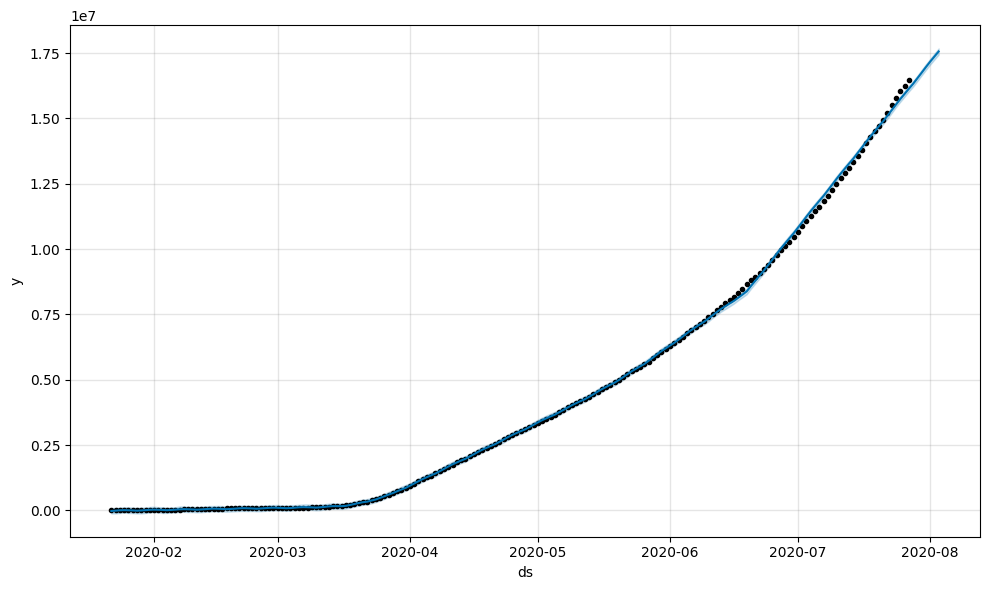

In [57]:
model.plot(forecast_confirmed)
plt.show()

# Forecasting for a Death cases

In [58]:
Deaths_cases = df.groupby("Date")["Deaths"].sum().reset_index()

In [59]:
Deaths_cases

,Date,Deaths
0,2020-01-22,17
1,2020-01-23,18
2,2020-01-24,26
3,2020-01-25,42
4,2020-01-26,56
...,...,...
183,2020-07-23,633506
184,2020-07-24,639650
185,2020-07-25,644517
186,2020-07-26,648621


In [60]:
# WE need to convert Date and Death column name into  ds(datestamp) and y(value-target)
prophet1_data = Deaths_cases.rename(columns={
    "Date" : "ds",
    "Deaths" : "y"
})

In [61]:
prophet1_data

,ds,y
0,2020-01-22,17
1,2020-01-23,18
2,2020-01-24,26
3,2020-01-25,42
4,2020-01-26,56
...,...,...
183,2020-07-23,633506
184,2020-07-24,639650
185,2020-07-25,644517
186,2020-07-26,648621


In [62]:
model1 = Prophet()

In [63]:
model1.fit(prophet1_data)

23:25:39 - cmdstanpy - INFO - Chain [1] start processing
23:25:39 - cmdstanpy - INFO - Chain [1] done processing


In [64]:
future_Death = model1.make_future_dataframe(periods=7,freq="D")

In [65]:
future_Death

,ds
0,2020-01-22
1,2020-01-23
2,2020-01-24
3,2020-01-25
4,2020-01-26
...,...
190,2020-07-30
191,2020-07-31
192,2020-08-01
193,2020-08-02


In [66]:
forecast_Death = model1.predict(future_Death)
forecast_Death

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-521.770784,-2696.022873,1163.705389,-521.770784,-521.770784,-191.377481,-191.377481,-191.377481,-191.377481,-191.377481,-191.377481,0.0,0.0,0.0,-713.148265
1,2020-01-23,-432.731501,-2096.510325,1792.330890,-432.731501,-432.731501,388.586602,388.586602,388.586602,388.586602,388.586602,388.586602,0.0,0.0,0.0,-44.144900
2,2020-01-24,-343.692219,-1415.732808,2530.178889,-343.692219,-343.692219,874.803913,874.803913,874.803913,874.803913,874.803913,874.803913,0.0,0.0,0.0,531.111694
3,2020-01-25,-254.652937,-1467.073034,2361.031985,-254.652937,-254.652937,727.302005,727.302005,727.302005,727.302005,727.302005,727.302005,0.0,0.0,0.0,472.649068
4,2020-01-26,-165.613654,-2228.617294,1662.789083,-165.613654,-165.613654,-165.700009,-165.700009,-165.700009,-165.700009,-165.700009,-165.700009,0.0,0.0,0.0,-331.313663
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,663132.991110,661424.297246,665577.849228,662814.073752,663426.298478,388.586602,388.586602,388.586602,388.586602,388.586602,388.586602,0.0,0.0,0.0,663521.577712
191,2020-07-31,668163.993407,666874.240265,671244.562586,667559.550374,668791.508711,874.803913,874.803913,874.803913,874.803913,874.803913,874.803913,0.0,0.0,0.0,669038.797320
192,2020-08-01,673194.995704,671485.606855,676200.967865,672263.744582,674128.016166,727.302005,727.302005,727.302005,727.302005,727.302005,727.302005,0.0,0.0,0.0,673922.297709
193,2020-08-02,678225.998001,675457.843609,680626.271682,676806.526812,679551.801503,-165.700009,-165.700009,-165.700009,-165.700009,-165.700009,-165.700009,0.0,0.0,0.0,678060.297992


In [67]:
forecast_Death[["yhat_lower","yhat_upper","yhat"]]

,yhat_lower,yhat_upper,yhat
0,-2696.022873,1163.705389,-713.148265
1,-2096.510325,1792.330890,-44.144900
2,-1415.732808,2530.178889,531.111694
3,-1467.073034,2361.031985,472.649068
4,-2228.617294,1662.789083,-331.313663
...,...,...,...
190,661424.297246,665577.849228,663521.577712
191,666874.240265,671244.562586,669038.797320
192,671485.606855,676200.967865,673922.297709
193,675457.843609,680626.271682,678060.297992


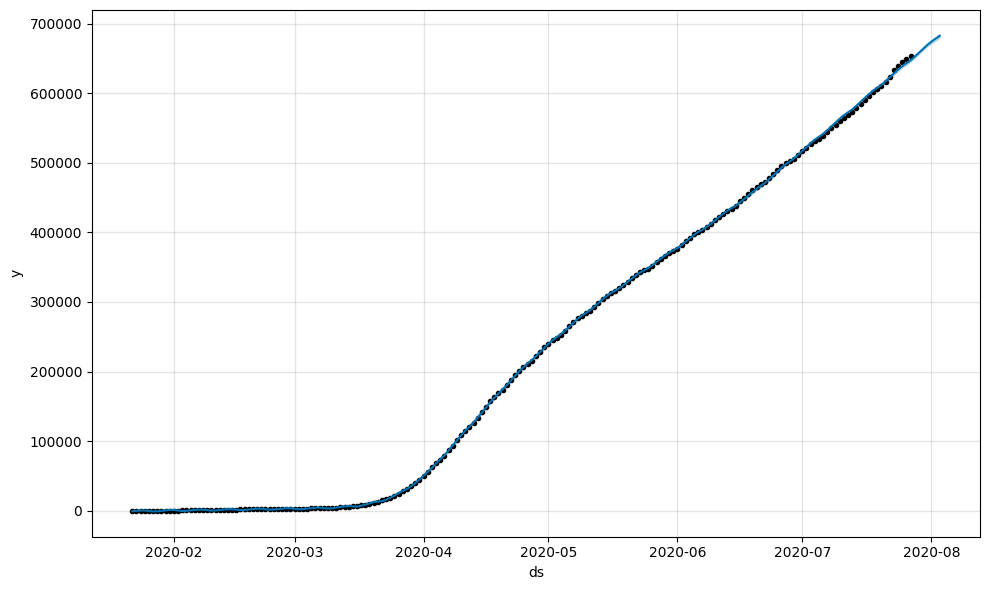

In [68]:
model1.plot(forecast_Death)
plt.show()

# Forecast for a Recovered Cases

In [69]:
Recovered_cases = df.groupby("Date")["Recovered"].sum().reset_index()

In [70]:
Recovered_cases

,Date,Recovered
0,2020-01-22,28
1,2020-01-23,30
2,2020-01-24,36
3,2020-01-25,39
4,2020-01-26,52
...,...,...
183,2020-07-23,8710969
184,2020-07-24,8939705
185,2020-07-25,9158743
186,2020-07-26,9293464


In [71]:
# WE need to convert Date and Death column name into  ds(datestamp) and y(value-target)
prophet2_data = Recovered_cases.rename(columns={
    "Date" : "ds",
    "Recovered" : "y"
})

In [72]:
prophet2_data

,ds,y
0,2020-01-22,28
1,2020-01-23,30
2,2020-01-24,36
3,2020-01-25,39
4,2020-01-26,52
...,...,...
183,2020-07-23,8710969
184,2020-07-24,8939705
185,2020-07-25,9158743
186,2020-07-26,9293464


In [73]:
model2 = Prophet()

In [74]:
model2.fit(prophet2_data)

23:25:40 - cmdstanpy - INFO - Chain [1] start processing
23:25:40 - cmdstanpy - INFO - Chain [1] done processing


In [75]:
future_Recovered = model2.make_future_dataframe(periods=7)

In [76]:
future_Recovered

,ds
0,2020-01-22
1,2020-01-23
2,2020-01-24
3,2020-01-25
4,2020-01-26
...,...
190,2020-07-30
191,2020-07-31
192,2020-08-01
193,2020-08-02


In [77]:
forecast_Recovered = model2.predict(future_Recovered)
forecast_Recovered

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-1.205747e+04,-9.670989e+04,6.511062e+04,-1.205747e+04,-1.205747e+04,-4840.306147,-4840.306147,-4840.306147,-4840.306147,-4840.306147,-4840.306147,0.0,0.0,0.0,-1.689777e+04
1,2020-01-23,-1.098613e+04,-8.924848e+04,6.668467e+04,-1.098613e+04,-1.098613e+04,1268.500733,1268.500733,1268.500733,1268.500733,1268.500733,1268.500733,0.0,0.0,0.0,-9.717631e+03
2,2020-01-24,-9.914796e+03,-7.698578e+04,7.855987e+04,-9.914796e+03,-9.914796e+03,6127.043529,6127.043529,6127.043529,6127.043529,6127.043529,6127.043529,0.0,0.0,0.0,-3.787753e+03
3,2020-01-25,-8.843461e+03,-7.526881e+04,7.636359e+04,-8.843461e+03,-8.843461e+03,9721.186705,9721.186705,9721.186705,9721.186705,9721.186705,9721.186705,0.0,0.0,0.0,8.777256e+02
4,2020-01-26,-7.772126e+03,-8.311757e+04,7.466561e+04,-7.772126e+03,-7.772126e+03,-915.435299,-915.435299,-915.435299,-915.435299,-915.435299,-915.435299,0.0,0.0,0.0,-8.687561e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,9.597260e+06,9.521992e+06,9.675570e+06,9.593231e+06,9.600880e+06,1268.500733,1268.500733,1268.500733,1268.500733,1268.500733,1268.500733,0.0,0.0,0.0,9.598529e+06
191,2020-07-31,9.733966e+06,9.671022e+06,9.822111e+06,9.725258e+06,9.740961e+06,6127.043529,6127.043529,6127.043529,6127.043529,6127.043529,6127.043529,0.0,0.0,0.0,9.740093e+06
192,2020-08-01,9.870671e+06,9.805505e+06,9.960660e+06,9.856709e+06,9.881668e+06,9721.186705,9721.186705,9721.186705,9721.186705,9721.186705,9721.186705,0.0,0.0,0.0,9.880392e+06
193,2020-08-02,1.000738e+07,9.923834e+06,1.009042e+07,9.987676e+06,1.002369e+07,-915.435299,-915.435299,-915.435299,-915.435299,-915.435299,-915.435299,0.0,0.0,0.0,1.000646e+07


In [78]:
forecast_Recovered[["yhat_lower","yhat_upper","yhat"]]

,yhat_lower,yhat_upper,yhat
0,-9.670989e+04,6.511062e+04,-1.689777e+04
1,-8.924848e+04,6.668467e+04,-9.717631e+03
2,-7.698578e+04,7.855987e+04,-3.787753e+03
3,-7.526881e+04,7.636359e+04,8.777256e+02
4,-8.311757e+04,7.466561e+04,-8.687561e+03
...,...,...,...
190,9.521992e+06,9.675570e+06,9.598529e+06
191,9.671022e+06,9.822111e+06,9.740093e+06
192,9.805505e+06,9.960660e+06,9.880392e+06
193,9.923834e+06,1.009042e+07,1.000646e+07


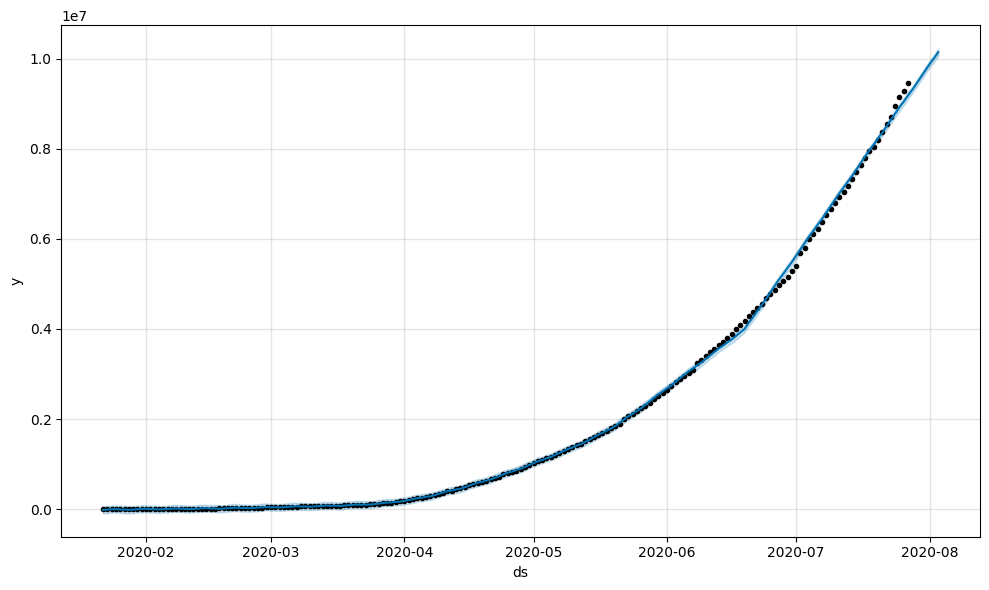

In [79]:
model2.plot(forecast_Recovered)
plt.show()

# Forecast for Active Cases

In [80]:
Active_cases = df.groupby("Date")["Active"].sum().reset_index()

In [81]:
Active_cases

,Date,Active
0,2020-01-22,510
1,2020-01-23,606
2,2020-01-24,879
3,2020-01-25,1353
4,2020-01-26,2010
...,...,...
183,2020-07-23,6166006
184,2020-07-24,6212290
185,2020-07-25,6243930
186,2020-07-26,6309711


In [82]:
# WE need to convert Date and Death column name into  ds(datestamp) and y(value-target)
prophet3_data = Active_cases.rename(columns={
    "Date" : "ds",
    "Active" : "y"
})

In [83]:
prophet3_data

,ds,y
0,2020-01-22,510
1,2020-01-23,606
2,2020-01-24,879
3,2020-01-25,1353
4,2020-01-26,2010
...,...,...
183,2020-07-23,6166006
184,2020-07-24,6212290
185,2020-07-25,6243930
186,2020-07-26,6309711


In [84]:
model3 = Prophet()

In [85]:
model3.fit(prophet3_data)

23:25:41 - cmdstanpy - INFO - Chain [1] start processing
23:25:41 - cmdstanpy - INFO - Chain [1] done processing


In [86]:
future_Active = model3.make_future_dataframe(periods=7)

In [87]:
future_Active

,ds
0,2020-01-22
1,2020-01-23
2,2020-01-24
3,2020-01-25
4,2020-01-26
...,...
190,2020-07-30
191,2020-07-31
192,2020-08-01
193,2020-08-02


In [88]:
forecast_Active = model3.predict(future_Active)
forecast_Active

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,3.938641e+02,-5.110526e+04,3.977798e+04,3.938641e+02,3.938641e+02,-5768.245993,-5768.245993,-5768.245993,-5768.245993,-5768.245993,-5768.245993,0.0,0.0,0.0,-5.374382e+03
1,2020-01-23,2.179134e+03,-4.548892e+04,4.287414e+04,2.179134e+03,2.179134e+03,-2565.782696,-2565.782696,-2565.782696,-2565.782696,-2565.782696,-2565.782696,0.0,0.0,0.0,-3.866492e+02
2,2020-01-24,3.964403e+03,-3.877527e+04,5.239435e+04,3.964403e+03,3.964403e+03,3219.381401,3219.381401,3219.381401,3219.381401,3219.381401,3219.381401,0.0,0.0,0.0,7.183784e+03
3,2020-01-25,5.749672e+03,-3.891712e+04,5.344492e+04,5.749672e+03,5.749672e+03,3129.568400,3129.568400,3129.568400,3129.568400,3129.568400,3129.568400,0.0,0.0,0.0,8.879241e+03
4,2020-01-26,7.534942e+03,-3.379043e+04,6.189636e+04,7.534942e+03,7.534942e+03,8182.557299,8182.557299,8182.557299,8182.557299,8182.557299,8182.557299,0.0,0.0,0.0,1.571750e+04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,6.483578e+06,6.437352e+06,6.530613e+06,6.480566e+06,6.486566e+06,-2565.782696,-2565.782696,-2565.782696,-2565.782696,-2565.782696,-2565.782696,0.0,0.0,0.0,6.481012e+06
191,2020-07-31,6.545831e+06,6.503225e+06,6.602933e+06,6.539299e+06,6.551952e+06,3219.381401,3219.381401,3219.381401,3219.381401,3219.381401,3219.381401,0.0,0.0,0.0,6.549050e+06
192,2020-08-01,6.608084e+06,6.566073e+06,6.658864e+06,6.597912e+06,6.617730e+06,3129.568400,3129.568400,3129.568400,3129.568400,3129.568400,3129.568400,0.0,0.0,0.0,6.611213e+06
193,2020-08-02,6.670337e+06,6.629013e+06,6.726169e+06,6.655888e+06,6.684020e+06,8182.557299,8182.557299,8182.557299,8182.557299,8182.557299,8182.557299,0.0,0.0,0.0,6.678519e+06


In [89]:
forecast_Active[["yhat_lower","yhat_upper","yhat"]]

,yhat_lower,yhat_upper,yhat
0,-5.110526e+04,3.977798e+04,-5.374382e+03
1,-4.548892e+04,4.287414e+04,-3.866492e+02
2,-3.877527e+04,5.239435e+04,7.183784e+03
3,-3.891712e+04,5.344492e+04,8.879241e+03
4,-3.379043e+04,6.189636e+04,1.571750e+04
...,...,...,...
190,6.437352e+06,6.530613e+06,6.481012e+06
191,6.503225e+06,6.602933e+06,6.549050e+06
192,6.566073e+06,6.658864e+06,6.611213e+06
193,6.629013e+06,6.726169e+06,6.678519e+06


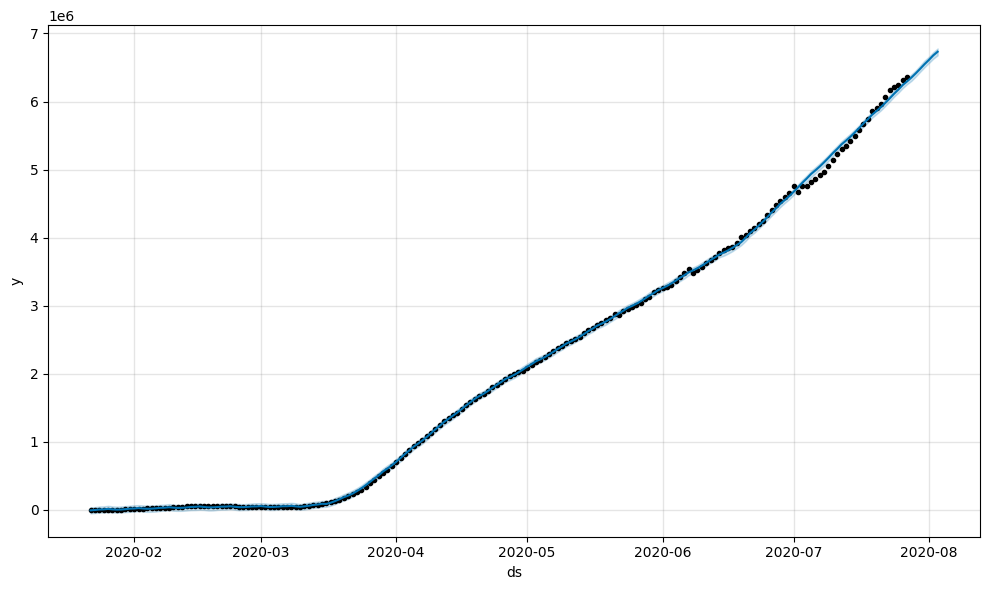

In [90]:
model3.plot(forecast_Active)
plt.show()